## Analyze Results

✅ Loaded: Riemannian Kernel (100 EigenPairs)
✅ Loaded: Riemannian Kernel (500 EigenPairs)
✅ Loaded: Riemannian Kernel (1000 EigenPairs)
✅ Loaded: SLE Kernel
⚠️  gap_start=950 or gap_end=1000 not found for 'Riemannian Kernel (1000 EigenPairs)' — plotting solid.


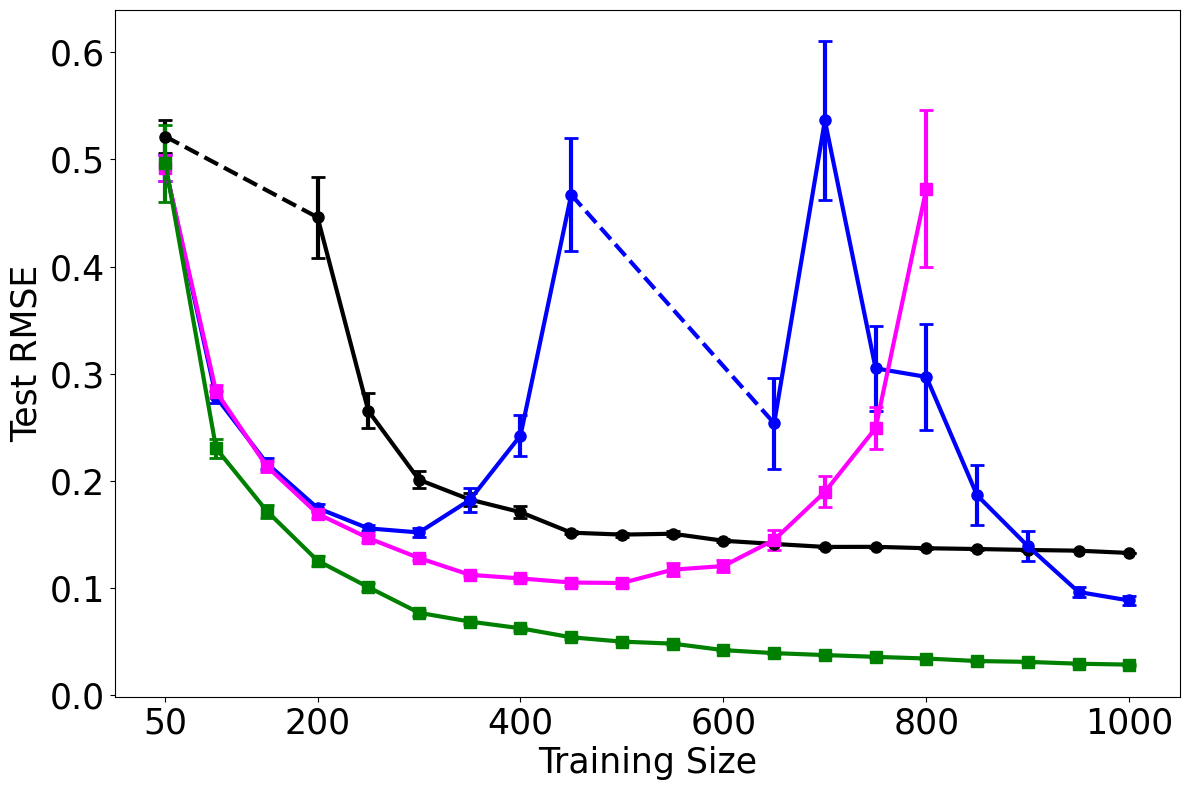

Saved: Dragon_Comparison_RMSE.pdf
⚠️  gap_start=950 or gap_end=1000 not found for 'Riemannian Kernel (1000 EigenPairs)' — plotting solid.


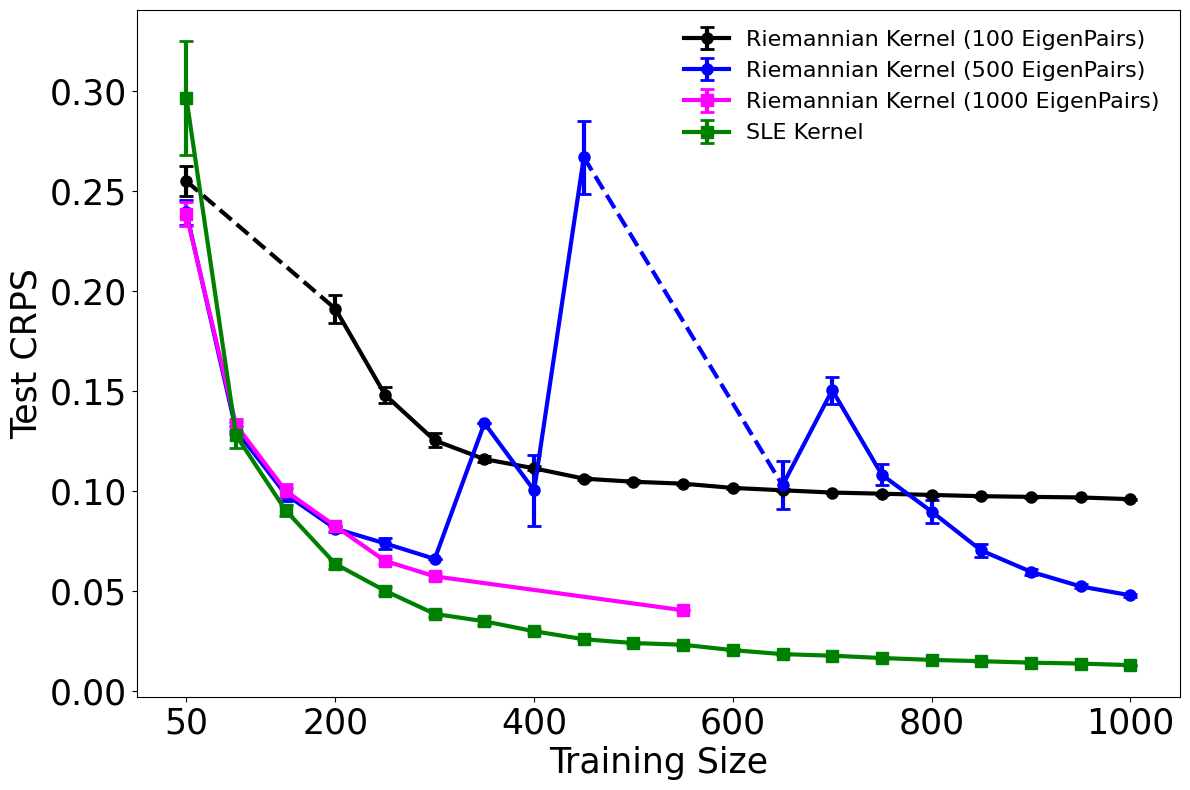

Saved: Dragon_Comparison_CRPS.pdf
⚠️  gap_start=950 or gap_end=1000 not found for 'Riemannian Kernel (1000 EigenPairs)' — plotting solid.


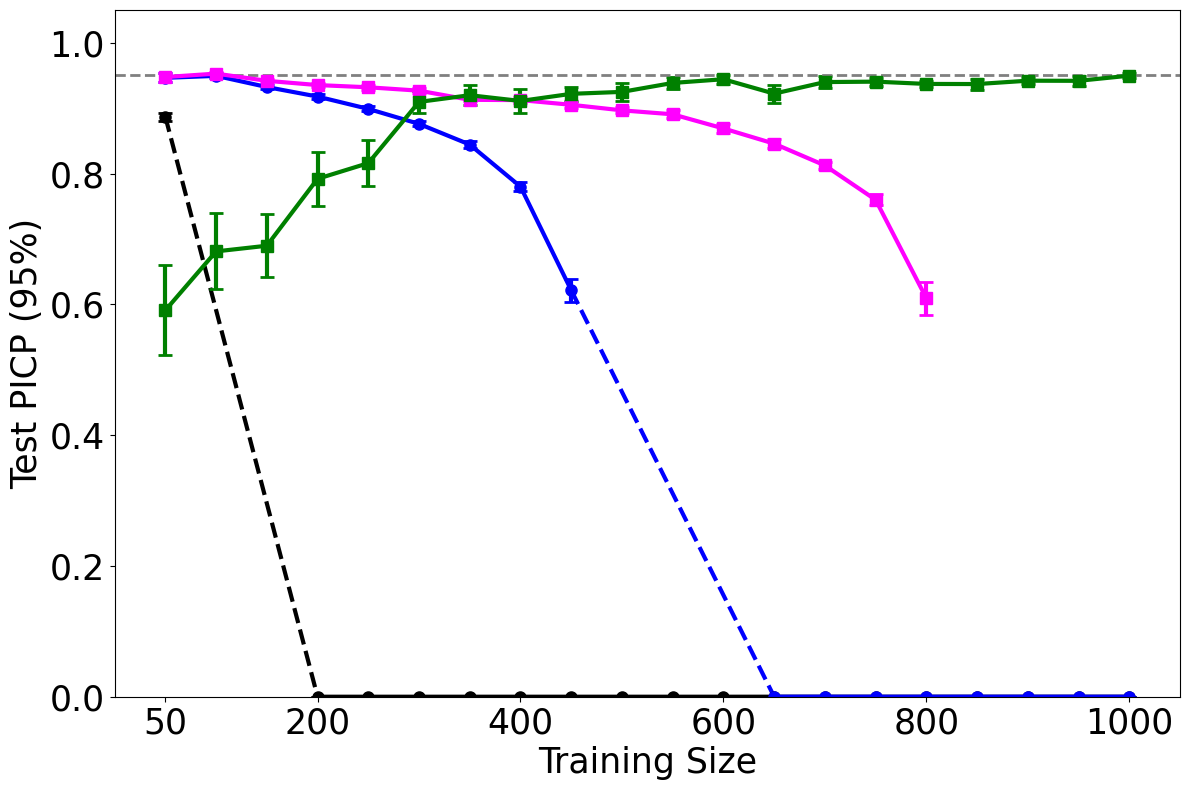

Saved: Dragon_Comparison_PICP.pdf


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIGURATION — only edit this section
# ============================================================
files_and_labels = [
    ('Riemannan Matern/dragon_example_manifold_matern_gp_experiment_results_100EigenPairs.json', 'Riemannian Kernel (100 EigenPairs)', 'black'),
    ('Riemannan Matern/dragon_example_manifold_matern_gp_experiment_results_500EigenPairs.json','Riemannian Kernel (500 EigenPairs)', 'blue'),
    ('Riemannan Matern/dragon_example_manifold_matern_gp_experiment_results_1000EigenPairs.json','Riemannian Kernel (1000 EigenPairs)', 'magenta'),
    # ('/pscratch/sd/m/malghal/Flexible_kernels/Dragon/dragon_example_gp_experiment_results.json',
    #  'SLE (RBF)', 'red'),
    ('Flexible kernel data/dragon_example_gp_experiment_results_Matern.json',
     'SLE Kernel', 'green'),
]

# ============================================================
# FUNCTIONS
# ============================================================
def load_and_process_results(filename):
    """Load results and organize by training size, including CRPS and PICP if present."""
    with open(filename, 'r') as f:
        results = json.load(f)

    organized = defaultdict(lambda: {
        'train_rmse': [],
        'test_rmse': [],
        'test_crps_mean': [],
        'test_picp': []
    })

    for result in results:
        if result.get('status') == 'failed' or 'error' in result:
            continue

        train_size = result['training_size']
        organized[train_size]['train_rmse'].append(result['train_rmse'])
        organized[train_size]['test_rmse'].append(result['test_rmse'])

        # Handle all key naming variants for CRPS (including typo 'my_crsp_mean')
        if 'test_crps mean' in result:
            crps_value = result['test_crps mean']
        elif 'my_crps_mean' in result:
            crps_value = result['my_crps_mean']
        elif 'my_crsp_mean' in result:          # typo variant
            crps_value = result['my_crsp_mean']
        else:
            crps_value = None

        if crps_value is not None:
            organized[train_size]['test_crps_mean'].append(crps_value)

        # Handle all key naming variants for PICP
        if 'test_picp' in result:
            picp_value = result['test_picp']
        elif 'my_picp' in result:
            picp_value = result['my_picp']
        else:
            picp_value = None

        if picp_value is not None:
            organized[train_size]['test_picp'].append(picp_value)

    return organized


def calculate_stats(organized_results):
    """Calculate mean and SEM for each training size, with IQR-based outlier removal.
    NaN values are ignored in all aggregations."""
    stats = {}

    for train_size, data in organized_results.items():
        test_rmses = np.array(data['test_rmse'], dtype=float)

        # Build outlier mask from test RMSE using IQR
        q1, q3 = np.percentile(test_rmses, 25), np.percentile(test_rmses, 75)
        iqr = q3 - q1
        mask = (test_rmses >= q1 - 1.5 * iqr) & (test_rmses <= q3 + 1.5 * iqr)

        def masked_stats(values):
            arr = np.array(values, dtype=float)
            if len(arr) == 0:
                return np.nan, np.nan
            arr = arr[mask[:len(arr)]]
            if len(arr) == 0:
                return np.nan, np.nan
            valid = arr[~np.isnan(arr)]
            if len(valid) == 0:
                return np.nan, np.nan
            return np.nanmean(arr), np.nanstd(arr) / np.sqrt(len(valid))

        train_mean, train_sem = masked_stats(data['train_rmse'])
        test_mean,  test_sem  = masked_stats(data['test_rmse'])
        crps_mean,  crps_sem  = masked_stats(data['test_crps_mean'])
        picp_mean,  picp_sem  = masked_stats(data['test_picp'])

        stats[train_size] = {
            'train_mean': train_mean, 'train_sem': train_sem,
            'test_mean':  test_mean,  'test_sem':  test_sem,
            'crps_mean':  crps_mean,  'crps_sem':  crps_sem,
            'picp_mean':  picp_mean,  'picp_sem':  picp_sem,
            'n_trials': int(mask.sum())
        }

    return stats


def plot_metric(all_stats, metric_mean, metric_sem, ylabel, filename,add_legened = False,
                ylim=None, reference_line=None, gap_configs=None):
    """
    Generic plotting function for any metric.

    gap_configs: list of per-dataset gap settings, aligned by index to all_stats.
                 Each entry is either None (solid line, no gap) or a dict:
                   {'gap_start': int, 'gap_end': int}
                 Example for 4 datasets where index 0 and 1 have gaps:
                   gap_configs=[
                       {'gap_start': 450, 'gap_end': 650},  # dataset 0
                       {'gap_start': 50,  'gap_end': 200},  # dataset 1
                       None,                                  # dataset 2
                       None,                                  # dataset 3
                   ]
    """
    plt.figure(figsize=(12, 8))

    for i, (stats, label, color) in enumerate(all_stats):
        train_sizes = sorted(stats.keys())
        means = np.array([stats[s][metric_mean] for s in train_sizes], dtype=float)
        sems  = np.array([stats[s][metric_sem]  for s in train_sizes], dtype=float)

        # Drop points where the mean is NaN; replace NaN sems with 0
        valid_mask  = ~np.isnan(means)
        if not np.any(valid_mask):
            print(f"⚠️  No valid data for '{label}' on metric '{metric_mean}' — skipping.")
            continue

        train_sizes = [s for s, v in zip(train_sizes, valid_mask) if v]
        means       = means[valid_mask].tolist()
        sems        = np.where(np.isnan(sems[valid_mask]), 0.0, sems[valid_mask]).tolist()

        # Resolve the gap config for this dataset (None if not specified)
        gap = (gap_configs[i] if gap_configs and i < len(gap_configs) else None)

        if gap is not None:
            gap_start = gap['gap_start']
            gap_end   = gap['gap_end']

            try:
                idx_start = train_sizes.index(gap_start)
                idx_end   = train_sizes.index(gap_end)

                # Segment before the gap (includes gap_start point)
                plt.errorbar(train_sizes[:idx_start + 1], means[:idx_start + 1],
                             yerr=sems[:idx_start + 1],
                             marker='o', linewidth=3, capsize=5, capthick=2,
                             label=label, color=color, markersize=8)
                # The gap itself (dashed, no error bars)
                plt.plot([train_sizes[idx_start], train_sizes[idx_end]],
                         [means[idx_start], means[idx_end]],
                         linestyle='--', linewidth=3, color=color)
                # Segment after the gap (includes gap_end point)
                plt.errorbar(train_sizes[idx_end:], means[idx_end:],
                             yerr=sems[idx_end:],
                             marker='o', linewidth=3, capsize=5, capthick=2,
                             color=color, markersize=8)

            except ValueError:
                # gap_start or gap_end not found after NaN filtering — fall back to solid
                print(f"⚠️  gap_start={gap_start} or gap_end={gap_end} not found for '{label}' — plotting solid.")
                plt.errorbar(train_sizes, means, yerr=sems,
                             marker='s', linewidth=3, capsize=5, capthick=2,
                             label=label, color=color, markersize=8)
        else:
            plt.errorbar(train_sizes, means, yerr=sems,
                         marker='s', linewidth=3, capsize=5, capthick=2,
                         label=label, color=color, markersize=8)

    if reference_line is not None:
        plt.axhline(y=reference_line, color='gray', linestyle='--',
                    linewidth=2, label=f'{reference_line:.0%} target')

    plt.xlabel('Training Size', fontsize=25)
    plt.ylabel(ylabel, fontsize=25)
    if add_legened:
        plt.legend(fontsize=16, frameon=False)
    #plt.grid(True, alpha=0.3)
    plt.xlim(0, 1050)
    plt.xticks([50, 200, 400, 600, 800, 1000], fontsize=25)
    plt.yticks(fontsize=25)
    if ylim:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.savefig(f'/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Dragon Results/{filename}', bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ============================================================
# LOAD ALL RESULTS
# ============================================================
all_stats = []
for filepath, label, color in files_and_labels:
    results = load_and_process_results(filepath)
    stats   = calculate_stats(results)
    all_stats.append((stats, label, color))
    print(f"✅ Loaded: {label}")

# ============================================================
# Point removal — comment out to show all points (no gaps)
# ============================================================
# 500 EigenPairs (index 0): remove 500, 550, 600
del all_stats[1][0][500]
del all_stats[1][0][550]
# del all_stats[1][0][600]

# 100 EigenPairs (index 1): remove 100, 150
del all_stats[0][0][100]
del all_stats[0][0][150]

# 100 EigenPairs (index 1): remove 100, 150
del all_stats[2][0][850]
del all_stats[2][0][900]
del all_stats[2][0][950]
del all_stats[2][0][1000]

# ============================================================
# Gap configs — aligned to files_and_labels by index
# ============================================================
gap_configs = [
    {'gap_start': 50,  'gap_end': 200},   # index 0: 100 EigenPairs
    {'gap_start': 450, 'gap_end': 650},   # index 1: 500 EigenPairs
    {'gap_start': 950, 'gap_end': 1000},   # index 1: 500 EigenPairs
    None,                                  # index 2: SLE (RBF)
    None,                                  # index 3: SLE (Matern)
]

# ============================================================
# PLOT 1 — Test RMSE
# ============================================================
plot_metric(all_stats,
            metric_mean='test_mean', metric_sem='test_sem',
            ylabel='Test RMSE',
            filename='Dragon_Comparison_RMSE.pdf',
            gap_configs=gap_configs)

# ============================================================
# PLOT 2 — CRPS Mean
# ============================================================
plot_metric(all_stats,
            metric_mean='crps_mean', metric_sem='crps_sem',
            ylabel='Test CRPS',
            filename='Dragon_Comparison_CRPS.pdf',
            gap_configs=gap_configs,
            add_legened = True)

# ============================================================
# PLOT 3 — PICP
# ============================================================
plot_metric(all_stats,
            metric_mean='picp_mean', metric_sem='picp_sem',
            ylabel='Test PICP (95%)',
            filename='Dragon_Comparison_PICP.pdf',
            ylim=(0, 1.05),
            reference_line=0.95,
            gap_configs=gap_configs)

In [4]:
train_sizes_of_interest = [ 400, 600,800]
metrics = [
    ('Test RMSE', 'test_mean', 'test_sem'),
    ('Test CRPS', 'crps_mean', 'crps_sem'),
    ('Test PICP', 'picp_mean', 'picp_sem'),
]

for metric_label, mean_key, sem_key in metrics:
    print(f"\n── {metric_label} ──")
    for stats, label, _ in all_stats:
        print(f"  {label}")
        for ts in train_sizes_of_interest:
            if ts in stats:
                mean = stats[ts][mean_key]
                sem  = stats[ts][sem_key]
                print(f"    Training Size {ts}: {mean:.4f} ± {sem:.4f}")
            else:
                print(f"    Training Size {ts}: not found")


── Test RMSE ──
  Riemannian Kernel (100 EigenPairs)
    Training Size 400: 0.1707 ± 0.0055
    Training Size 600: 0.1440 ± 0.0012
    Training Size 800: 0.1370 ± 0.0010
  Riemannian Kernel (500 EigenPairs)
    Training Size 400: 0.2423 ± 0.0196
    Training Size 600: 4.2572 ± 0.5800
    Training Size 800: 0.2970 ± 0.0494
  Riemannian Kernel (1000 EigenPairs)
    Training Size 400: 0.1088 ± 0.0022
    Training Size 600: 0.1204 ± 0.0059
    Training Size 800: 0.4726 ± 0.0734
  SLE (Matern)
    Training Size 400: 0.0623 ± 0.0021
    Training Size 600: 0.0419 ± 0.0010
    Training Size 800: 0.0340 ± 0.0007

── Test CRPS ──
  Riemannian Kernel (100 EigenPairs)
    Training Size 400: 0.1112 ± 0.0011
    Training Size 600: 0.1014 ± 0.0004
    Training Size 800: 0.0979 ± 0.0004
  Riemannian Kernel (500 EigenPairs)
    Training Size 400: 0.1002 ± 0.0176
    Training Size 600: 1.0568 ± 0.1472
    Training Size 800: 0.0896 ± 0.0056
  Riemannian Kernel (1000 EigenPairs)
    Training Size 400: na